In [1]:
import os
import glob
import sys
import dill
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from yaml import safe_load, YAMLError, dump
from tabulate import tabulate
from scipy.interpolate import RectBivariateSpline
from scipy.stats import norm

import config as cfg 
import post_bdtlh_efficiency_finder as eff_finder
import bdt_lh_cut_opt_with_n_interp as opt
plt.style.use('fcc.mplstyle')

In [2]:
#load dictionary of N_remaining from spline (ie. N remaining fior different BFT cuts - essentially efficiency map)
save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(opt.set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

with open(os.path.join(opt.set_outputpath(save_path), "N_remaining_dictionary"), "rb") as dill_file:
    N_dict = dill.load(dill_file)

#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)

#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

In [3]:
# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = opt.run_2d_optimisation(interp_N_dict,lrange_plot=(0.995,1) ,hrange_plot=(0.995,1), nlh=500 , sig_BF=1e-6, incl_ZqqBFerror = False)
indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]
print(l_cut)
print(h_cut)

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       168.757 |               0.9996 |               0.9996 |
+---------------+----------------------+----------------------+
0.9996492985971944
0.9996292585170341


In [4]:
#cut data on optimal BDT cut
cut_data = full_data.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')


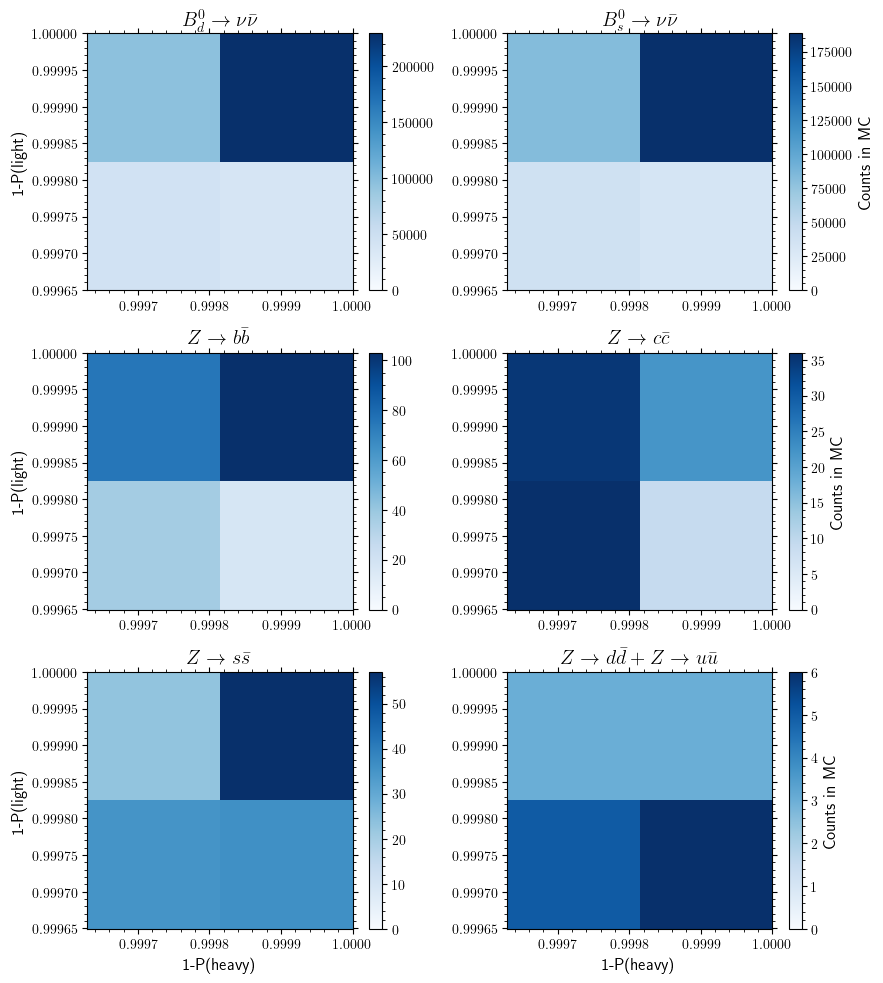

In [5]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(9,10))

axs[0, 0].set_title(cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
axs[0,0].set_ylabel('1-P(light)') 

axs[0, 1].set_title(cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'])

axs[1, 0].set_title(cfg.titles['p8_ee_Zbb_ecm91'])
axs[1,0].set_ylabel('1-P(light)')

axs[1, 1].set_title(cfg.titles['p8_ee_Zcc_ecm91'])

axs[2, 0].set_title(cfg.titles['p8_ee_Zss_ecm91'])
axs[2,0].set_xlabel('1-P(heavy)')
axs[2,0].set_ylabel('1-P(light)')


axs[2, 1].set_title(cfg.titles['p8_ee_Zud_ecm91'])
axs[2,1].set_xlabel('1-P(heavy)')

h00=axs[0,0].hist2d(cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h0=axs[0,1].hist2d(cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False, range = [[h_cut, 1], [l_cut, 1]])
h1 = axs[1, 0].hist2d(cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h2 = axs[1, 1].hist2d(cut_data[cut_data['decay']=='p8_ee_Zcc_ecm91']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zcc_ecm91']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h3 = axs[2, 0].hist2d(cut_data[cut_data['decay']=='p8_ee_Zss_ecm91']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zss_ecm91']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h4 = axs[2, 1].hist2d(cut_data[cut_data['decay']=='p8_ee_Zud_ecm91']["P_not_heavy"], cut_data[cut_data['decay']=='p8_ee_Zud_ecm91']["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])

# Visualizing colorbar 

fig.colorbar(h00[3], ax=axs[0, 0])
fig.colorbar(h0[3], ax=axs[0, 1], label='Counts in MC')
fig.colorbar(h1[3], ax=axs[1, 0])
fig.colorbar(h2[3], ax=axs[1, 1], label='Counts in MC')
fig.colorbar(h3[3], ax=axs[2, 0])
fig.colorbar(h4[3], ax=axs[2, 1], label='Counts in MC')


plt.show()

In [6]:
h00

(array([[ 44688.,  95483.],
        [ 38848., 229503.]]),
 array([0.99962926, 0.99981463, 1.        ]),
 array([0.9996493 , 0.99982465, 1.        ]),
 <matplotlib.collections.QuadMesh at 0x7f0dbb45d000>)

In [7]:
for decay in cfg.sample_allocations['leptonic_background']:
    df = cut_data[cut_data['decay']== decay]
    print(decay)
    print(len(df))

p8_ee_Ztautau_ecm91
0
p8_ee_Zmumu_ecm91
0
p8_ee_Zee_ecm91
0


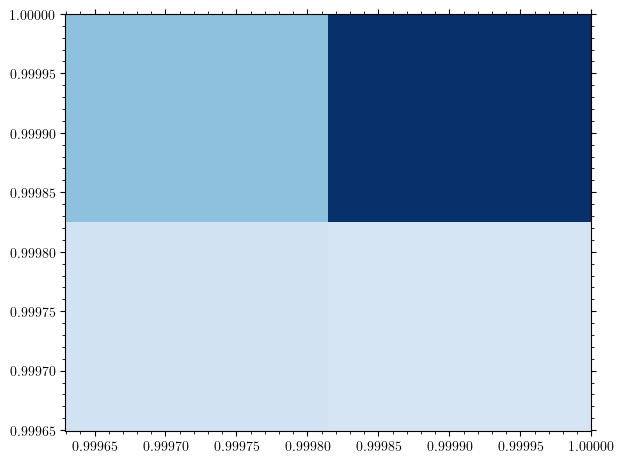

In [8]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]

def get_eff_from_nMC_list(N_dict_MC, eventsProcessed_dict = cfg.eventsProcessed):

    efficienies = {}
    efficiencies_err = {}
    
    for decay in N_dict_MC.keys():
        eventsProcessed = eventsProcessed_dict[decay]
        N_post = N_dict_MC[decay]
        
        #calc efficiency
        total_efficiency = N_post/eventsProcessed
        efficienies[decay] = total_efficiency
        #print(f"efficiency: {total_efficiency}")
    
        # calculating error using bayesian error formula See <https://indico.cern.ch/event/66256/contributions/2071577/attachments/1017176/1447814/EfficiencyErrors.pdf>
        # Variance in an efficiency k/n is (k+1)(k+2)/(n+2)(n+3) - (k+1)^2/(n+2)^2
        var = ((N_post+1)*(N_post+2))/((eventsProcessed+2)*(eventsProcessed+3)) - ((N_post+1)/(eventsProcessed+2))**2
        error = np.sqrt(var)
        efficiencies_err[decay] = error
        #print(f"efficiency error: {error}")
    
    return efficienies, efficiencies_err, N_dict_MC
                

eventsProcessed_dict = cfg.eventsProcessed    
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
components =  ['hadronic_background','combined_signal']
i=0
tot_arr = [0,0,0,0]
samples = flatten_list([cfg.sample_allocations[component] for component in components])

N_dict_MC={}
for decay in samples:
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=(2,2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    N_dict_MC[decay] =  h[0] 
N_dict_MC

efficienies, efficiencies_err, N_dict_MC = get_eff_from_nMC_list(N_dict_MC)


In [9]:

#make st works for dict of efficiency lists or dict of efficiencies

def get_n_expected_components(efficiencies, efficiencies_err, signal_bf=1e-6): #set up to take efficiencies which is a disctionary of arrays or dict of floats
    
    # Dict to store output
    per_sample_n_expect_dict = {}
    per_sample_frac_eff_err={}
    per_sample_frac_BFZbb_err={}
    
    # COMPUTING EXPECTATION
    for sample in efficiencies.keys():
        N_z = cfg.N_z
        bfs_val = cfg.branching_fractions[sample][0] #value=1 for signal
        bfs_err = cfg.branching_fractions[sample][1] #value=0 for signal modes
        
        eff_val = efficiencies[sample]
        eff_err_val = efficiencies_err[sample]
        
        frac_eff_err = np.where(eff_val != 0, eff_err_val / eff_val, 0) 

        num = N_z*bfs_val*eff_val

        if sample in cfg.sample_allocations['combined_signal']:
            num *= 2*cfg.branching_fractions['p8_ee_Zbb_ecm91'][0]*cfg.prod_frac[sample][0]*signal_bf

        frac_BFZbb_err = bfs_err/bfs_val #0 for signal

        if sample in cfg.sample_allocations['combined_signal']:
            frac_BFZbb_err = cfg.branching_fractions['p8_ee_Zbb_ecm91'][1]/cfg.branching_fractions['p8_ee_Zbb_ecm91'][0]

        per_sample_n_expect_dict[sample] = num
        per_sample_frac_eff_err[sample] = frac_eff_err
        per_sample_frac_BFZbb_err[sample] = frac_BFZbb_err

    return per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err


per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err=get_n_expected_components(efficienies, efficiencies_err,signal_bf=1e-6)



def get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err, incl_BFZbb_err=True):
    B= np.sum(np.stack([per_sample_n_expect_dict[k] for k in cfg.sample_allocations['hadronic_background']]), axis=0)
    S= np.sum(np.stack([per_sample_n_expect_dict[k] for k in cfg.sample_allocations['combined_signal']]), axis=0)

    B_eff_var= np.sum(np.stack([(per_sample_frac_eff_err[k]*per_sample_n_expect_dict[k])**2 for k in cfg.sample_allocations['hadronic_background']]), axis=0)
    S_eff_var= np.sum(np.stack([(per_sample_frac_eff_err[k]*per_sample_n_expect_dict[k])**2 for k in cfg.sample_allocations['combined_signal']]), axis=0)

    B_BF_var = np.sum(np.stack([(per_sample_frac_BFZbb_err[k]*per_sample_n_expect_dict[k])**2 for k in cfg.sample_allocations['hadronic_background']]), axis=0)
    S_BF_var = np.sum(np.stack([(per_sample_frac_BFZbb_err[k]*per_sample_n_expect_dict[k]) for k in cfg.sample_allocations['combined_signal']]), axis=0)**2

    if incl_BFZbb_err == True:
        B_err = np.sqrt(B_eff_var+B_BF_var)
        S_err = np.sqrt(S_eff_var+S_BF_var)

    else:
        B_err = np.sqrt(B_eff_var)
        S_err = np.sqrt(S_eff_var)

    return S, B, S_err, B_err

S, B, S_err, B_err = get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err)


0.046708960655237296
[[21006.45184846 23091.12129427]
 [17705.72123736 27615.25511614]]


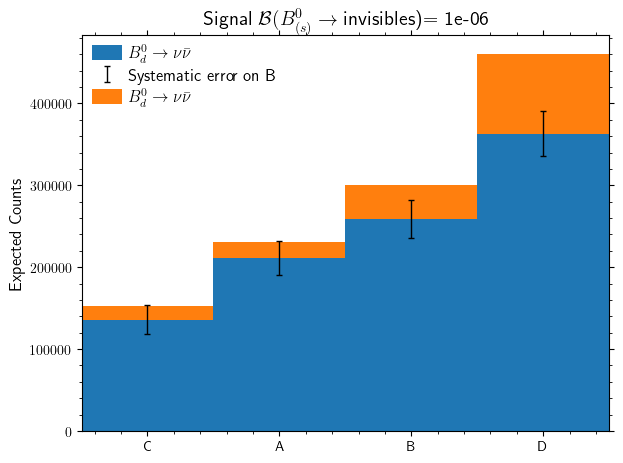

In [10]:
tot_arr=[0,0,0,0]
for i in range(2):
    num=[B,S]
    h=num[i]
    x = np.array([['A','B'],['C','D']])
    plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[1,0],h[0,0],h[0,1],h[1,1]],label=cfg.titles[decay], bottom=tot_arr, width=1.0)
    if i==0:
        plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],[B[1,0],B[0,0],B[0,1],B[1,1]], [B_err[1,0],B_err[0,0],B_err[0,1],B_err[1,1]],label='Systematic error on B',  fmt='None', ecolor='black')
        
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[1,0],h[0,0],h[0,1],h[1,1]])]
    
plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')
print(np.sqrt(np.sum(B_err**2))/np.sum(B))
print(B_err)


In [11]:
print(f'B = {B}')
print(f'B_err = {B_err}')
print(f'frac_B_err = {B_err/B}')

print(f'S = {S}')
print(f'S_err = {S_err}')
print(f'frac_S_err = {S_err/S}\n')

print(f'Bq ={per_sample_n_expect_dict}\n')
print(f'Bq_frac_eff_err ={per_sample_frac_eff_err}\n')
print(f'Bq_frac_Zqq_err ={per_sample_frac_BFZbb_err}')

print(0.04711572 * B)
print(B_err)
print(np.sqrt(np.sum(B_err**2))/np.sum(B))

B = [[211322.26368566 259125.767781  ]
 [136129.49546059 362897.55101174]]
B_err = [[21006.45184846 23091.12129427]
 [17705.72123736 27615.25511614]]
frac_B_err = [[0.09940482 0.08911164]
 [0.13006528 0.07609656]]
S = [[19192.47776116 41042.58868538]
 [16631.27336029 97790.63795607]]
S_err = [[ 99.09537117 174.66424886]
 [ 89.82651373 362.9352587 ]]
frac_S_err = [[0.00516324 0.00425568]
 [0.00540106 0.00371135]]

Bq ={'p8_ee_Zbb_ecm91': array([[ 76506.59679649, 155080.93945234],
       [ 35151.6796092 , 212977.82351455]]), 'p8_ee_Zcc_ecm91': array([[51991.80101895, 50547.58432398],
       [12997.95025474, 31772.76728936]]), 'p8_ee_Zss_ecm91': array([[ 66551.17844443,  43733.6315492 ],
       [ 68452.6406857 , 108383.34775236]]), 'p8_ee_Zud_ecm91': array([[16272.68742579,  9763.61245548],
       [19527.22491095,  9763.61245548]]), 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([[ 3344.6504448,  7181.1919872],
       [ 2854.5011712, 16401.3631488]]), 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([[15

# Method check using one bin only

In [17]:
# Using same method to calculate error on single bin
#If instead only use one bin
eventsProcessed_dict = cfg.eventsProcessed    
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
components =  ['hadronic_background','combined_signal']
i=0
tot_arr = [0,0,0,0]
samples = flatten_list([cfg.sample_allocations[component] for component in components])

N_dict_MC={}
for decay in samples:
    h=np.histogram2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=(1,1),density=False,range = [[h_cut, 1], [l_cut, 1]])
    N_dict_MC[decay] =  h[0] 
N_dict_MC

efficienies, efficiencies_err, N_dict_MC = get_eff_from_nMC_list(N_dict_MC)

per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err=get_n_expected_components(efficienies, efficiencies_err,signal_bf=1e-6)

S, B, S_err, B_err = get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err)

print(np.sqrt(np.sum(B_err**2))/np.sum(B))
print(B_err)

0.04711571511026776
[[45677.51157868]]


In [20]:
## for one bin 

print(f'B = {B}')
print(f'B_err = {B_err}')
print(f'frac_B_err = {B_err/B}')

print(f'S = {S}')
print(f'S_err = {S_err}')
print(f'frac_S_err = {S_err/S}\n')

print(f'Bq ={per_sample_n_expect_dict}\n')
print(f'Bq_frac_eff_err ={per_sample_frac_eff_err}\n')
print(f'Bq_frac_Zqq_err ={per_sample_frac_BFZbb_err}')

B = [[969475.07793899]]
B_err = [[45677.51157868]]
frac_B_err = [[0.04711572]]
S = [[174656.97776291]]
S_err = [[614.47029972]]
frac_S_err = [[0.00351815]]

Bq ={'p8_ee_Zbb_ecm91': array([[479717.03937258]]), 'p8_ee_Zcc_ecm91': array([[147310.10288703]]), 'p8_ee_Zss_ecm91': array([[287120.79843168]]), 'p8_ee_Zud_ecm91': array([[55327.1372477]]), 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([[29781.706752]]), 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([[144875.27101091]])}

Bq_frac_eff_err ={'p8_ee_Zbb_ecm91': array([[0.06579454]]), 'p8_ee_Zcc_ecm91': array([[0.09949893]]), 'p8_ee_Zss_ecm91': array([[0.08164785]]), 'p8_ee_Zud_ecm91': array([[0.24956709]]), 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([[0.00155702]]), 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([[0.00141184]])}

Bq_frac_Zqq_err ={'p8_ee_Zbb_ecm91': 0.003306878306878307, 'p8_ee_Zcc_ecm91': 0.017456359102244388, 'p8_ee_Zss_ecm91': 0.03787878787878788, 'p8_ee_Zud_ecm91': 0.050351721584598295, 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': 0.003306878306

# Comparison -  Taking total B error assigning B_err/2 per bin (means if make flawed independent assumption and sum in quadrature recover total error) - much closer to if calculate per bin


0
p8_ee_Zbb_ecm91
0
n_=479717.0393725775
frac_err=0.06579454044092639
p8_ee_Zcc_ecm91
1
n_=147310.1028870338
frac_err=0.099498926162192
p8_ee_Zss_ecm91
2
n_=287120.7984316778
frac_err=0.08164785476581024
p8_ee_Zud_ecm91
3
n_=55327.13724769753
frac_err=0.2495670934786479
frac_err_B=0.0455639308257057
1
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
0
n_=29781.706752000002
frac_err=0.0015570223827375154
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
1
n_=144875.2710109091
frac_err=0.0014118437523427667


Text(0, 0.5, 'Expected Counts')

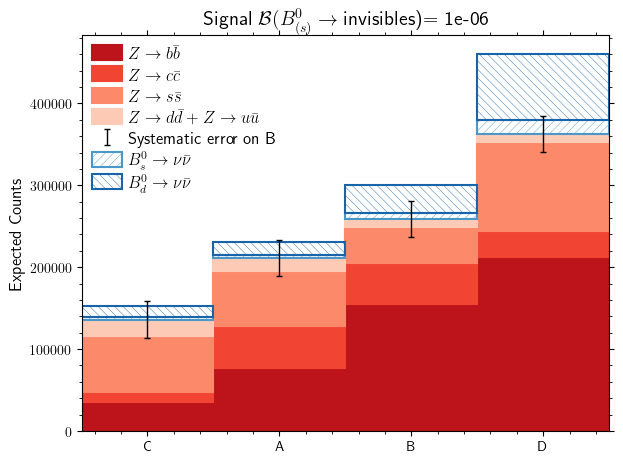

In [13]:
## Taking total B error assigning B_err/2 per bin (means if make flawed independent assumption and sum in quadrature recover total error) - much closer to if calculate per bin

signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]

components =  ['hadronic_background','combined_signal']
colors = [plt.cm.Reds_r(np.linspace(0, 1, len(cfg.sample_allocations[components[0]])+2)[1:-1]), plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations[components[1]])+4)[3:-1])]
hatching = [['','','','',], ['////',r'\\\\']]


k=0
tot_arr = [0,0,0,0]

for allocation in cfg.sample_allocations:
    i=0
    tot_component_arr = [0,0,0,0]
    if allocation not in components:
        continue
    
    print(k)
    samples =cfg.sample_allocations[allocation]
    for decay in samples:
        print(decay)
        print(i)
        df = cut_data[cut_data['decay']== decay]
        #calculate weight
        eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
        n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
        n_exp_arr.append(n_exp[decay])
        n_exp_err_arr.append(n_err[decay])
        
        hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
        print(f'n_={n_exp[decay]}')
        print(f'frac_err={err[decay]/eff[decay]}')
    
        color = colors[k][i]
        facecolor=[color,'none']
        h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)
    
        x = np.array([['A','B'],['C','D']])
        plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],edgecolor=color, bottom=tot_arr, width=1.0, hatch = hatching[k][i],facecolor=facecolor[k],lw=1.5)
        tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
        tot_component_arr = [sum(x) for x in zip(tot_component_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
        i+=1
    
    if allocation == 'hadronic_background':
        B_height = tot_component_arr
        B_var = sum(n_exp_err_arr[i]**2 for i in range(len(n_exp_err_arr)))
        B_err = np.sqrt(B_var)
        plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],B_height, B_err/2, label='Systematic error on B',  fmt='None', ecolor='black')
        print(f'frac_err_B={B_err/np.sum(tot_arr)}')
    if allocation == 'combined_signal':
        S_var = sum(n_exp_err_arr[i]**2 for i in [4,5])
        S_err = np.sqrt(S_var)
                
    k+=1


plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')

# Comparison -  Taking total B fractional error and multiplying per bin (statistically nonsense)


0
p8_ee_Zbb_ecm91
0
n_=479717.0393725775
frac_err=0.06579454044092639
p8_ee_Zcc_ecm91
1
n_=147310.1028870338
frac_err=0.099498926162192
p8_ee_Zss_ecm91
2
n_=287120.7984316778
frac_err=0.08164785476581024
p8_ee_Zud_ecm91
3
n_=55327.13724769753
frac_err=0.2495670934786479
frac_err_B=0.0455639308257057
1
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
0
n_=29781.706752000002
frac_err=0.0015570223827375154
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
1
n_=144875.2710109091
frac_err=0.0014118437523427667
total fractional error on B = 0.0386083888358588
Naively summing errors=19763.163843548115
Naively summing errors - fractional of B=0.017273498831087915


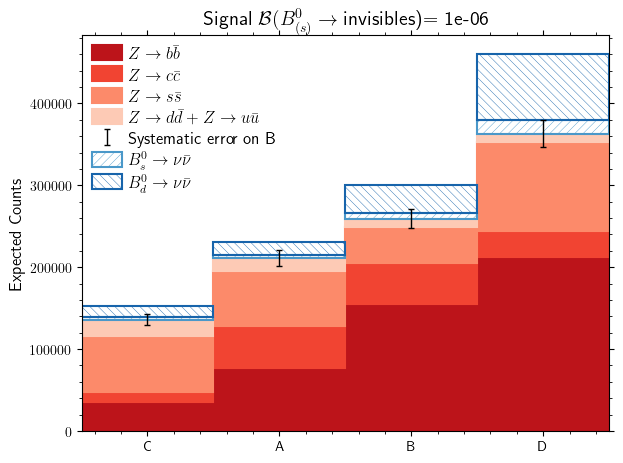

In [16]:
## Taking total B fractional error and multiplying per bin (statistically nonsense)
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]

components =  ['hadronic_background','combined_signal']
colors = [plt.cm.Reds_r(np.linspace(0, 1, len(cfg.sample_allocations[components[0]])+2)[1:-1]), plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations[components[1]])+4)[3:-1])]
hatching = [['','','','',], ['////',r'\\\\']]


k=0
tot_arr = [0,0,0,0]

for allocation in cfg.sample_allocations:
    i=0
    tot_component_arr = [0,0,0,0]
    if allocation not in components:
        continue
    
    print(k)
    samples =cfg.sample_allocations[allocation]
    for decay in samples:
        print(decay)
        print(i)
        df = cut_data[cut_data['decay']== decay]
        #calculate weight
        eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
        n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
        n_exp_arr.append(n_exp[decay])
        n_exp_err_arr.append(n_err[decay])
        
        hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
        print(f'n_={n_exp[decay]}')
        print(f'frac_err={err[decay]/eff[decay]}')
    
        color = colors[k][i]
        facecolor=[color,'none']
        h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)
    
        x = np.array([['A','B'],['C','D']])
        plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],edgecolor=color, bottom=tot_arr, width=1.0, hatch = hatching[k][i],facecolor=facecolor[k],lw=1.5)
        tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
        tot_component_arr = [sum(x) for x in zip(tot_component_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
        i+=1
    
    if allocation == 'hadronic_background':
        B_height = tot_component_arr
        B_var = sum(n_exp_err_arr[i]**2 for i in range(len(n_exp_err_arr)))
        B_err = np.sqrt(B_var)
        plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],B_height, [ B_err/np.sum(tot_arr) *B_height[i] for i in range(len(B_height))],label='Systematic error on B',  fmt='None', ecolor='black')
        print(f'frac_err_B={B_err/np.sum(tot_arr)}')
    if allocation == 'combined_signal':
        S_var = sum(n_exp_err_arr[i]**2 for i in [4,5])
        S_err = np.sqrt(S_var)
                
    k+=1


plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')
print(f'total fractional error on B = {B_err/np.sum(tot
                                                    _arr)}')
print(f'Naively summing errors={np.sqrt(sum([ (B_err/np.sum(tot_arr) *B_height[i])**2 for i in range(len(B_height))]))}')
print(f'Naively summing errors - fractional of B={np.sqrt(sum([ (B_err/np.sum(tot_arr) *B_height[i])**2 for i in range(len(B_height))]))/np.sum(tot_arr)}')